Project code

In [2]:
import json

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.metrics import classification_report
from simpletransformers.classification import ClassificationModel, ClassificationArgs
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter

## Preprocessing for NER dataset

## Dataset statistics for NER dataset

## Model for NER

## Preprocessing for sentiment classification dataset

In [12]:
files_sentiment_path = ['sentiment_analysis_data/training_data_1.json', 
                        'sentiment_analysis_data/training_data_2.json']

def mergeJSONfiles(filename):
    training_data_sentiment = {}
    counter = 1
    for file in filename:
        with open(file, 'r', encoding='utf-8') as sentiment_data:
            data = json.load(sentiment_data)
            for key in data:
                training_data_sentiment[str(counter)] = data[key]
                counter += 1
    
    with open('sentiment_analysis_data/merged_training_data.json', 'w', encoding='utf-8') as output_file:
        json.dump(training_data_sentiment, output_file, indent=4)
    
mergeJSONfiles(files_sentiment_path)

In [14]:
sentiment_file_path = 'sentiment_analysis_data/merged_training_data.json'

with open(sentiment_file_path, 'r') as sentiment_data:
    training_data_sentiment = json.load(sentiment_data)
    
print(training_data_sentiment['4000000'])

{'sentiment_label': 'positive', 'text_of_tweet': "Makes My Blood Run Red-White-And-Blue: I agree that every American should read this book -- and everybody else for that matter. I don't agree that it's scholarly. Rather, it's a joy to read -- easy to understand even for a person with two master's degrees! Between McElroy's chapter on How American Culture was Formed and Ken Burns' Lewis & Clark, I don't know which makes my blood run red-white-and-bluer. And as a child of the anti-establishment `60s, it's done a lot toward helping me understand why we Americans do what we do. It's the best history book I've ever read, the best history course I've ever taken or taught. I'm buying it for my home library for my grandchildren to use as a resource. We're also using it as a resource for a book on urban planning."}


In [62]:
tsv_file = 'sentiment-topic-test.tsv'
test_data_sentiment = pd.read_table(tsv_file,sep='\t')
test_data_sentiment.to_csv('testing_data_sentiment_topic.csv',index=False)

In [70]:
test_data_sentiment_csv = pd.read_csv('testing_data_sentiment_topic.csv')
test_data_dict = {}
test_data_dict.update(test_data_sentiment_csv['sentiment'])
print(test_data_dict)

{0: 'positive', 1: 'positive', 2: 'positive', 3: 'neutral', 4: 'neutral', 5: 'positive', 6: 'positive', 7: 'negative', 8: 'neutral', 9: 'neutral', 10: 'negative', 11: 'positive', 12: 'negative', 13: 'neutral', 14: 'negative', 15: 'neutral', 16: 'negative', 17: 'negative'}


In [73]:
all_text = json.load(open('sentiment_analysis_data/merged_training_data.json'))

for id_, tweet in all_text.items():
    print(id_, tweet)
    #print(id_, tweet['sentiment_label'], tweet['text_of_tweet'])
    #break

FileNotFoundError: [Errno 2] No such file or directory: 'sentiment_analysis_data/merged_training_data.json'

## Dataset statistics for sentiment classification

In [71]:
frequency_dict = {}
freq_dict = {}

for id_, tweet in all_text.items():
    if tweet['sentiment_label'] not in frequency_dict:
        frequency_dict[tweet['sentiment_label']] = 1
    else:
        frequency_dict[tweet['sentiment_label']] += 1
        
for sentiment in test_data_dict.values():
    if sentiment not in freq_dict:
        freq_dict[sentiment] = 1
    else:
        freq_dict[sentiment] += 1
    
print(f"Training data class distribution: {frequency_dict}")
print(f"Testing data class distribution: {freq_dict}")

Training data class distribution: {'positive': 2000000, 'negative': 2000000}
Testing data class distribution: {'positive': 6, 'neutral': 6, 'negative': 6}


In [72]:
import math
import nltk

def entropy(labels):
    freqdist = nltk.FreqDist(labels)
    probs = [freqdist.freq(l) for l in freqdist]
    return -sum(p * math.log(p,2) for p in probs)

print(entropy(frequency_dict))
print(entropy(freq_dict))

1.0
1.584962500721156


## VADER Model for sentiment classification

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import spacy

vader_model = SentimentIntensityAnalyzer()
nlp = spacy.load('en_core_web_sm')



## SVM model for sentiment classification

## Preprocessing for topic classification dataset

In [23]:
topic_path = 'big_data.csv'

topic_test_data = 'testing_data_sentiment_topic.csv'

training_data_topic = pd.read_csv(topic_path)
training_data_topic = training_data_topic.drop(columns=['Unnamed: 0'])

testing_data_topic = pd.read_csv(topic_test_data)
testing_data_topic = testing_data_topic.drop(columns=['sentence_id', 'sentiment'])

print(training_data_topic.shape)
print(training_data_topic.head())
print(testing_data_topic.shape)
print(testing_data_topic.head())

# Dataset link: https://www.kaggle.com/datasets/aronferencz/topic-analysis-dataset-sportbookmovie

(120307, 2)
                                              review label
0  I'm only a third way in. Shipped lightening fa...  book
1  "There have been so many times when I was scar...  book
2  The media could not be loaded. I personally ha...  book
3  I have been a fan of Britney's music since the...  book
4  Whether or not you’re a fan, it’s a great read...  book
(18, 2)
                                            sentence   topic
0  The atmosphere at the stadium tonight was elec...  sports
1  The game was so intense I forgot to breathe at...  sports
2           It had me hooked from the first chapter.    book
3  It’s more of a slow burn than a page-turner, b...    book
4  It’s split into two timelines, which keeps it ...    book


In [24]:
print(training_data_topic['review'], training_data_topic['label'])

0         I'm only a third way in. Shipped lightening fa...
1         "There have been so many times when I was scar...
2         The media could not be loaded. I personally ha...
3         I have been a fan of Britney's music since the...
4         Whether or not you’re a fan, it’s a great read...
                                ...                        
120302     VAL GARDENA, Italy (Reuters) - Max Rauffer be...
120303    Red Sox general manager Theo Epstein acknowled...
120304    The Miami Dolphins will put their courtship of...
120305    PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...
120306    INDIANAPOLIS -- All-Star Vince Carter was trad...
Name: review, Length: 120307, dtype: object 0           book
1           book
2           book
3           book
4           book
           ...  
120302    sports
120303    sports
120304    sports
120305    sports
120306    sports
Name: label, Length: 120307, dtype: object


In [25]:
print(testing_data_topic['sentence'], testing_data_topic['topic'])

0     The atmosphere at the stadium tonight was elec...
1     The game was so intense I forgot to breathe at...
2              It had me hooked from the first chapter.
3     It’s more of a slow burn than a page-turner, b...
4     It’s split into two timelines, which keeps it ...
5     I could watch this film a hundred times and st...
6     Best thriller I’ve seen in ages. Had me on the...
7     How do you concede three goals in ten minutes?...
8     They rotated their squad for the cup game, whi...
9     The trailer gave away most of the plot, but th...
10    The protagonist was so whiny I wanted to throw...
11    The author’s writing style is so unique – poet...
12    I don't get how was it supposed to work withou...
13    It's still 0-0 so far, so way too early to tel...
14    I don't get the appeal at all, it's just a cou...
15    Did you hear the screenplay for it was origina...
16    It's really incredibly impressive to mess up s...
17    The only way it's helped me is by keeping 

In [26]:
training_data_topic['review_processed'] = training_data_topic['review'].astype(str).map(lambda x: re.sub(r'[,\.!?]', '', x) if x != 'nan' else '')

# Removing 'br' from data
training_data_topic['review_processed'] = training_data_topic['review_processed'].map(lambda x: re.sub(r'\bbr\b', '', x))

# Convert the titles to lowercase
training_data_topic['review_processed'] = training_data_topic['review_processed'].str.lower()

testing_data_topic['sentence'] = testing_data_topic['sentence'].str.lower()

# Print out the first rows of papers
training_data_topic['review_processed'].head()

0    i'm only a third way in shipped lightening fas...
1    "there have been so many times when i was scar...
2    the media could not be loaded i personally hav...
3    i have been a fan of britney's music since the...
4    whether or not you’re a fan it’s a great read ...
Name: review_processed, dtype: object

In [27]:
training_data_topic.head()

,review,label,review_processed
0,I'm only a third way in. Shipped lightening fa...,book,i'm only a third way in shipped lightening fas...
1,"""There have been so many times when I was scar...",book,"""there have been so many times when i was scar..."
2,The media could not be loaded. I personally ha...,book,the media could not be loaded i personally hav...
3,I have been a fan of Britney's music since the...,book,i have been a fan of britney's music since the...
4,"Whether or not you’re a fan, it’s a great read...",book,whether or not you’re a fan it’s a great read ...


In [28]:
testing_data_topic.head()

,sentence,topic
0,the atmosphere at the stadium tonight was elec...,sports
1,the game was so intense i forgot to breathe at...,sports
2,it had me hooked from the first chapter.,book
3,"it’s more of a slow burn than a page-turner, b...",book
4,"it’s split into two timelines, which keeps it ...",book


## Dataset statistics for topic modelling

In [32]:
train = pd.DataFrame({'text': training_data_topic['review_processed'], 'labels' : training_data_topic['label']})
test = pd.DataFrame({'text': testing_data_topic['sentence'], 'labels' : testing_data_topic['topic']})

print(f"Training data for BERT: {train}")
print(train.shape)
print('-' * 100)
print(f"Testing data for BERT: {test}")
print(test.shape)

Training data for BERT:                                                      text  labels
0       i'm only a third way in shipped lightening fas...    book
1       "there have been so many times when i was scar...    book
2       the media could not be loaded i personally hav...    book
3       i have been a fan of britney's music since the...    book
4       whether or not you’re a fan it’s a great read ...    book
...                                                   ...     ...
120302   val gardena italy (reuters) - max rauffer bec...  sports
120303  red sox general manager theo epstein acknowled...  sports
120304  the miami dolphins will put their courtship of...  sports
120305  pittsburgh at ny giants time: 1:30 pm line: st...  sports
120306  indianapolis -- all-star vince carter was trad...  sports

[120307 rows x 2 columns]
(120307, 2)
----------------------------------------------------------------------------------------------------
Testing data for BERT:                      

In [49]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')


def clean_text(text):
    # Remove quotation marks and empty strings
    text = re.sub(r'["``]', '', text)  # Remove " and ``
    text = re.sub(r"''", '', text)  # Remove '' strings
    return text

def truncate_text(text, head_tokens=128, tail_tokens=382, max_length=510):
    text = clean_text(text)
    tokens = word_tokenize(text)
    if len(tokens) > max_length:
        return " ".join(tokens[:head_tokens] + tokens[-tail_tokens:])
    return text

training_data_topic['review_processed'] = training_data_topic['review_processed'].astype(str).map(truncate_text)
testing_data_topic['sentence'] = testing_data_topic['sentence'].astype(str).map(truncate_text)

train = pd.DataFrame({'text': training_data_topic['review_processed'], 'labels': training_data_topic['label']})
test = pd.DataFrame({'text': testing_data_topic['sentence'], 'labels': testing_data_topic['topic']})

# Model configuration based off of paper: Sun-etal-2020-Fine tuning BERT for Text Classification (pages 4 'Hyperparameters', page 5 'Dealing with long texts' 'Truncation methods')
# head + tail method used here

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/robertostoica/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [50]:
print(f"Training data for BERT:\n{train.head()}")
print(train.shape)
print(f"Sentence example training: {train['text'][10]}")
print('-' * 100)
print(f"Testing data for BERT:\n{test.head()}")
print(test.shape)
print(f"Sentence example testing: {test['text'][0]}")

Training data for BERT:
                                                text labels
0  i 'm only a third way in shipped lightening fa...   book
1  there have been so many times when i was scare...   book
2  the media could not be loaded i personally hav...   book
3  i have been a fan of britney 's music since th...   book
4  whether or not you’re a fan it’s a great read ...   book
(120307, 2)
Sentence example training: i 'll admit i rarely watched  friends  when episodes first aired my wife started binge watching it a couple years ago or so probably during the pandemic and so i started watching it with her i do think that i was a little too hard on the show though as i always thought that it was a bit of a  seinfeld   rip-off  in reality there are enough differences in the shows that now after watching the entire series of each i 've relaxed my criticism a bitand i rarely read autobiographies or what people usually call  memoirs  nowadays i usually am reading true-crime books in partic

In [51]:
train_label_counts = Counter(train['labels'])

test_label_counts = Counter(test['labels'])

print("Class distribution in training data:", train_label_counts)
print("Class distribution in testing data:", test_label_counts)

#Class distribution in training data: Counter({'movie': 50000, 'sports': 36726, 'book': 33581})
#Class distribution in testing data: Counter({'sports': 6, 'book': 6, 'movie': 6})

Class distribution in training data: Counter({'movie': 50000, 'sports': 36726, 'book': 33581})
Class distribution in testing data: Counter({'sports': 6, 'book': 6, 'movie': 6})


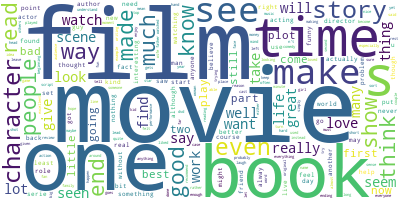

In [52]:
long_string = ','.join(list(training_data_topic['review_processed'].values))

wordcloud = WordCloud(background_color="white", max_words=1000, contour_width=3, contour_color='steelblue')

wordcloud.generate(long_string)

wordcloud.to_image()

/var/folders/lc/kpr2rnx93q52qglqhvd6c6vw0000gn/T/ipykernel_25435/2938581420.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_pos, y=counts, palette='husl')


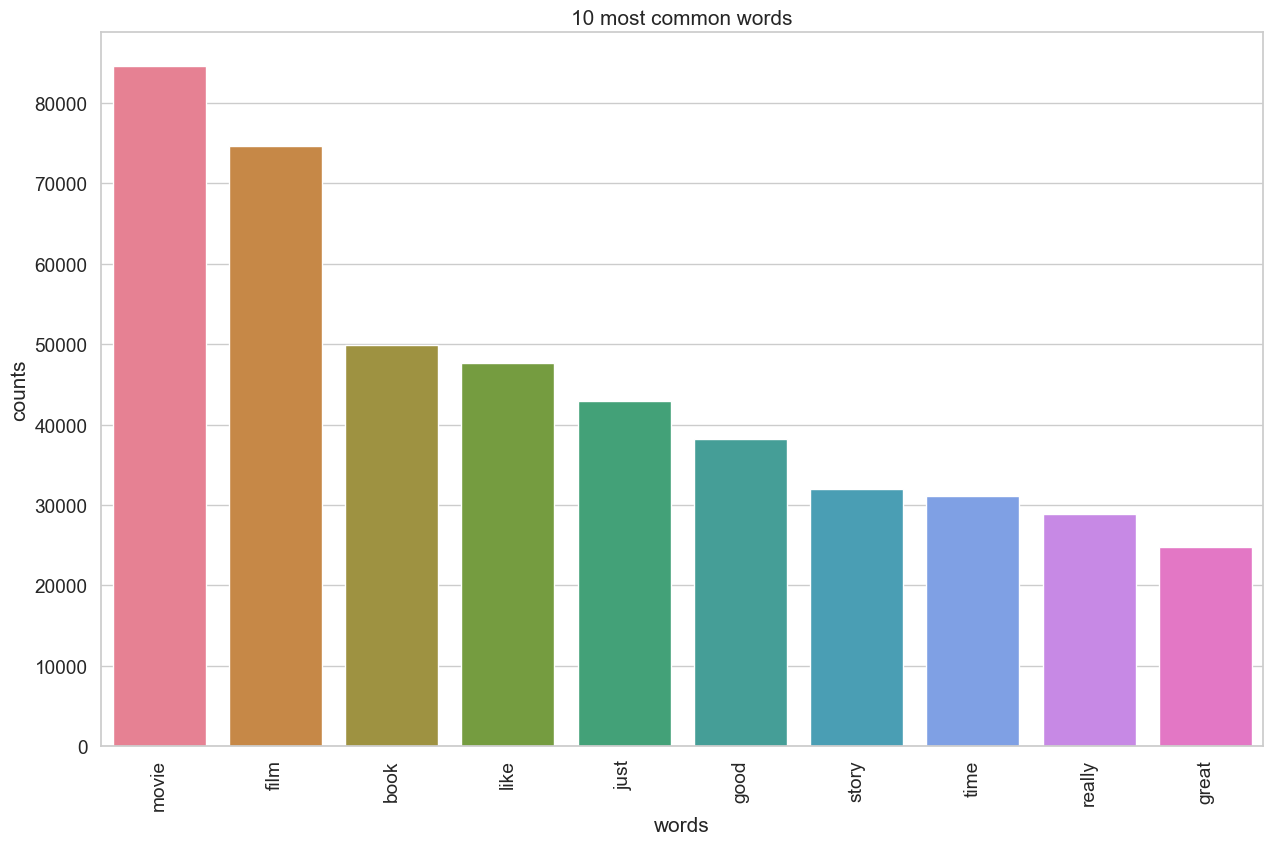

In [53]:
sns.set_style('whitegrid')
%matplotlib inline

# Helper function
def plot_10_most_common_words(count_data, count_vectorizer):
    words = count_vectorizer.get_feature_names_out()
    total_counts = np.zeros(len(words))
    for t in count_data:
        total_counts+=t.toarray()[0]
    
    count_dict = (zip(words, total_counts))
    count_dict = sorted(count_dict, key=lambda x:x[1], reverse=True)[0:10]
    words = [w[0] for w in count_dict]
    counts = [w[1] for w in count_dict]
    x_pos = np.arange(len(words)) 
    
    plt.figure(2, figsize=(15, 15/1.6180))
    plt.subplot(title='10 most common words')
    sns.set_context("notebook", font_scale=1.25, rc={"lines.linewidth": 2.5})
    sns.barplot(x=x_pos, y=counts, palette='husl')
    plt.xticks(x_pos, words, rotation=90) 
    plt.xlabel('words')
    plt.ylabel('counts')
    plt.show()

# Initialise the count vectorizer with the English stop words
count_vectorizer = CountVectorizer(stop_words='english')

# Fit and transform the processed titles
count_data = count_vectorizer.fit_transform(training_data_topic['review_processed'])

# Visualise the 10 most common words
plot_10_most_common_words(count_data, count_vectorizer)

## Model for topic classification

In [54]:
from sklearn.model_selection import train_test_split

train, dev = train_test_split(train, test_size=0.1, random_state=0, 
                               stratify=train[['labels']])

In [55]:
print(len(train))
print("train:", train[['labels']].value_counts(sort=False))
train.head(3)

108276
train: labels
book      30223
movie     45000
sports    33053
Name: count, dtype: int64


,text,labels
15333,i wish i had this book before my first child w...,book
88827,is cristiano ronaldo coming back to manchester...,sports
78115,all the reviewers are making one big mistake t...,movie


In [56]:
print(len(dev))
print("dev:", dev[['labels']].value_counts(sort=False))
dev.head(3)

12031
dev: labels
book      3358
movie     5000
sports    3673
Name: count, dtype: int64


,text,labels
2042,amazing book,book
8978,on time good quality,book
115010,homestead florida (ticker) -- kurt busch overc...,sports


In [66]:
# Model configuration
bert_args = ClassificationArgs()

bert_args.overwrite_output_dir=True
bert_args.evaluate_during_training=True

bert_args.num_train_epochs=10
bert_args.train_batch_size=32
bert_args.learning_rate=5e-5
bert_args.max_seq_length=512

bert_args.warmup_steps = 10000

bert_args.use_early_stopping=True
bert_args.early_stopping_delta=0.01

bert_args.early_stopping_metric='eval_loss'
bert_args.early_stopping_metric_minimize=True
bert_args.early_stopping_patience=8
bert_args.evaluate_during_training_steps=32

# Model configuration based off of paper: Sun-etal-2020-Fine tuning BERT for Text Classification (pages 4 'Hyperparameters', page 5 'Catastrophic Forgetting')
# and due to the needs of the training data labeled as big_data.csv

In [67]:
steps_per_epoch = int(np.ceil(len(train) / float(bert_args.train_batch_size)))
print('Each epoch will have {:,} steps.'.format(steps_per_epoch)) # 64 steps = validating 2 times per epoch

Each epoch will have 3,384 steps.


In [ ]:
model = ClassificationModel('bert', 'bert-base-cased', num_labels=3, args=bert_args, use_cuda=False)

In [ ]:
print(str(model.args).replace(',', '\n'))

In [ ]:
_, history = model.train_model(train, eval_df=dev) 

In [ ]:
train_loss = history['train_loss']
eval_loss = history['eval_loss']
plt.plot(train_loss, label='Training loss')
plt.plot(eval_loss, label='Evaluation loss')
plt.title('Training and evaluation loss')
plt.legend()

In [ ]:
result, model_outputs, wrong_predictions = model.eval_model(dev)
result

In [ ]:
predicted, probabilities = model.predict(test.text.to_list())
test['predicted'] = predicted

In [ ]:
test.head(5)

In [ ]:
print(classification_report(test['labels'], test['predicted']))